https://nbviewer.org/github/georgebv/pyextremes-notebooks/blob/master/notebooks/EVA%20basic.ipynb

https://nbviewer.org/github/georgebv/pyextremes-notebooks/blob/master/notebooks/tutorials/threshold%20selection.ipynb

In [ ]:
!pip install rasterio
!pip install pyextremes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
from pathlib import Path
from pyextremes import EVA
from pyextremes import plot_parameter_stability
import pyextremes
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [ ]:
def unzip_rainfall_data(zip_path, extract_path):
    """
    Unzip the folder containing grid rainfall CSVs to the specified extraction path.

    Parameters:
    - zip_path: Path to the ZIP file
    - extract_path: Path to extract the CSVs (RainfallGrid folder)
    """
    extract_path = Path(extract_path)
    extract_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Unzipped rainfall data to {extract_path}")


In [ ]:
unzip_rainfall_data("000Rainfall_GRID_Data.zip", "output")

Unzipped rainfall data to output


In [ ]:
# Directory containing the CSV files
input_dir = 'output'
output_dir = 'results'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [ ]:
return_periods = list(range(1, 1001))


In [ ]:
# Prepare a dictionary to collect results by return period
results_by_return_period = {rp: [] for rp in return_periods}

# Initialize dictionary to store results for all grid points
results = {}


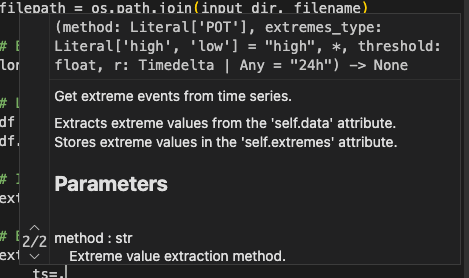

In [ ]:
# Process each CSV file
for filename in os.listdir(input_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(input_dir, filename)

        # Extract longitude and latitude from filename
        lon_lat = filename.replace('.csv', '')

        data = (
                pd
                .read_csv(filepath, index_col=0, parse_dates=True)
                .sort_index(ascending=True)
                .dropna()
                )

        data = data['Rainfall_mm'].astype(float).squeeze()

        # Initialize Extremes object with the time series
        model = EVA(data = data)

        threshold_data = float(np.percentile(data,98))

        # Extract peaks over threshold at 98% quantile
        model.get_extremes(
            method='POT',
            extremes_type='high',
            threshold=threshold_data,
            r="24h",
        )


        min_extremes_required = 2
        # Check if enough extremes for fitting
        if len(model.extremes) <= min_extremes_required:
          print(f"Not enough extremes extracted for {lon_lat}, skipping model fitting.")
          continue


        # Fit the GPD model to extracted extremes
        model.fit_model()

        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                # Extract only the first value (return level) from the tuple
                ret_level = ret_level_tuple[0]
                results_by_return_period[rp].append({
                    'longitude_latitude': lon_lat,
                    'return_level': ret_level
                })
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")



        # Get summary with return values and confidence intervals
        try:
            summary_df = model.get_summary(
                return_period=return_periods,
                return_period_size='365.2425D',
                alpha = 0.95

            )

            print(summary_df)

            # Reset index to make return_period a column
            summary_df = summary_df.reset_index().rename(columns={'index': 'return period'})
            # Add longitude_latitude column
            summary_df['longitude_latitude'] = lon_lat
            # Reorder columns
            summary_df = summary_df[['longitude_latitude', 'return period', 'return value', 'lower ci', 'upper ci']]
            # Save summary to CSV
            summary_output_path = os.path.join(output_dir, f'summary_{lon_lat}.csv')
            summary_df.to_csv(summary_output_path, index=False)
        except Exception as e:
            print(f"Failed to get summary for {lon_lat}: {e}")

'''
        # Initialize result dictionary for this grid point
        results[lon_lat] = {'longitude_latitude': lon_lat}

        # Estimate return levels
        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                ret_level = ret_level_tuple[0]
                results[lon_lat][f'return_level_{rp}years'] = ret_level
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")
                results[lon_lat][f'return_level_{rp}years'] = None



# Convert results to DataFrame
result_df = pd.DataFrame(list(results.values()))

# Save combined results to a single CSV
output_path = os.path.join(output_dir, 'return_levels_all_periods.csv')
result_df.to_csv(output_path, index=False)
'''

'''
        # Estimate return levels
        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                ret_level = ret_level_tuple[0]
                results_by_return_period[rp].append({
                    'longitude_latitude': lon_lat,
                    'return_level': ret_level
                })
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")

# Save results for each return period
for rp, results in results_by_return_period.items():
    result_df = pd.DataFrame(results)
    output_path = os.path.join(output_dir, f'return_level_{rp}years.csv')
    result_df.to_csv(output_path, index=False)'''

               return value    lower ci     upper ci
return period                                       
1.0                    -inf         NaN          NaN
2.0                    -inf         NaN          NaN
3.0                    -inf         NaN          NaN
4.0                    -inf         NaN          NaN
5.0              165.296893  163.591601   166.517912
...                     ...         ...          ...
996.0            233.340333  190.721711  4886.827140
997.0            233.340435  190.721717  4892.659326
998.0            233.340537  190.721722  4898.492846
999.0            233.340638  190.721728  4904.327697
1000.0           233.340739  190.721734  4910.163880

[1000 rows x 3 columns]
               return value    lower ci     upper ci
return period                                       
1.0                    -inf         NaN          NaN
2.0                    -inf         NaN          NaN
3.0                    -inf         NaN          NaN
4.0                  

KeyboardInterrupt: 

In [ ]:
import os
import zipfile

# Define the results directory (where CSV files are stored)
results_dir = 'results'  # Replace with actual path to results folder

# Define the output path for the ZIP file
zip_output_path = os.path.join(results_dir, '000results_archive.zip')

# Create a ZIP file and add all CSV files from the results directory
with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir(results_dir):
        if filename.endswith('.csv'):
            file_path = os.path.join(results_dir, filename)
            # Add file to ZIP, using just the filename (not full path) in the archive
            zipf.write(file_path, os.path.basename(filename))

print(f"All CSV files in {results_dir} have been zipped into {zip_output_path}")

All CSV files in results have been zipped into results/000results_archive.zip


In [ ]:
data = (
                pd
                .read_csv("output/117.05053541969069_7.850035908112533.csv", index_col=0, parse_dates=True)
                .sort_index(ascending=True)
                .dropna()
        )

data = data['Rainfall_mm'].astype(float).squeeze()

        # Initialize Extremes object with the time series
model = EVA(data = data)

threshold_data = float(np.percentile(data,98))

        # Extract peaks over threshold at 98% quantile
model.get_extremes(
            method='POT',
            extremes_type='high',
            threshold=threshold_data,
            r="24h",
)


        # Fit the GPD model to extracted extremes
model.fit_model()



FileNotFoundError: [Errno 2] No such file or directory: 'output/117.05053541969069_7.850035908112533.csv'

In [ ]:
threshold_data